### Plots
In this file I'm going to attempt to recreate some plots that we created in RStudio using matplotlib because I suck at using this library

In [1]:
from sportsdataverse import nba
import pandas as pd

In [2]:
player_games = nba.load_nba_player_boxscore(seasons=2024)
pbp = nba.load_nba_pbp(seasons=2024)

player_games = pd.DataFrame(player_games)
pbp = pd.DataFrame(pbp)

100%|██████████| 1/1 [00:01<00:00,  1.71s/it]


In [3]:
print(player_games.columns.tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]


In [6]:
print(player_games.head(3).to_string())

          0     1  2           3                   4        5                  6  7          8       9          10    11   12   13   14   15   16   17   18   19   20   21   22   23   24   25   26    27    28     29     30                31     32  33               34                                                              35             36  37                38             39                40                                                 41   42      43      44    45     46  47 48       49      50              51   52                                                 53      54      55   56
0  401656363  2024  3  2024-06-17 2024-06-18 00:30:00  4278078    P.J. Washington  6  Mavericks  Dallas  Mavericks  34.0  2.0  7.0  0.0  5.0  0.0  0.0  0.0  6.0  6.0  3.0  0.0  2.0  4.0  3.0  -26   4.0  True  False  False  COACH'S DECISION  False  25  P.J. Washington  https://a.espncdn.com/i/headshots/nba/players/full/4278078.png  Power Forward  PF  Dallas Mavericks  s:40~l:46~t:6  dallas-mave

no column names just numbers. gotta rename them

In [9]:
column_mapping = {
    0: "game_id",
    1: "season",
    2: "season_type",
    3: "game_date",
    4: "game_date_time",
    5: "athlete_id",
    6: "athlete_display_name",
    7: "team_id",
    8: "team_name",
    9: "team_location",
    10: "team_short_display_name",
    11: "minutes",
    12: "field_goals_made",
    13: "field_goals_attempted",
    14: "three_point_field_goals_made",
    15: "three_point_field_goals_attempted",
    16: "free_throws_made",
    17: "free_throws_attempted",
    18: "offensive_rebounds",
    19: "defensive_rebounds",
    20: "rebounds",
    21: "assists",
    22: "steals",
    23: "blocks",
    24: "turnovers",
    25: "fouls",
    26: "plus_minus",
    27: "points",
    28: "starter",
    29: "ejected",
    30: "did_not_play",
    31: "reason",
    32: "active",
    33: "athlete_jersey",
    34: "athlete_short_name",
    35: "athlete_headshot_href",
    36: "athlete_position_name",
    37: "athlete_position_abbreviation",
    38: "team_display_name",
    39: "team_uid",
    40: "team_slug",
    41: "team_logo",
    42: "team_abbreviation",
    43: "team_color",
    44: "team_alternate_color",
    45: "home_away",
    46: "team_winner",
    47: "team_score",
    48: "opponent_team_id",
    49: "opponent_team_name",
    50: "opponent_team_location",
    51: "opponent_team_display_name",
    52: "opponent_team_abbreviation",
    53: "opponent_team_logo",
    54: "opponent_team_color",
    55: "opponent_team_alternate_color",
    56: "opponent_team_score"
}

# Rename all columns in the DataFrame
player_games = player_games.rename(columns=column_mapping)

In [11]:
# now check:
print(player_games.columns.tolist())

['game_id', 'season', 'season_type', 'game_date', 'game_date_time', 'athlete_id', 'athlete_display_name', 'team_id', 'team_name', 'team_location', 'team_short_display_name', 'minutes', 'field_goals_made', 'field_goals_attempted', 'three_point_field_goals_made', 'three_point_field_goals_attempted', 'free_throws_made', 'free_throws_attempted', 'offensive_rebounds', 'defensive_rebounds', 'rebounds', 'assists', 'steals', 'blocks', 'turnovers', 'fouls', 'plus_minus', 'points', 'starter', 'ejected', 'did_not_play', 'reason', 'active', 'athlete_jersey', 'athlete_short_name', 'athlete_headshot_href', 'athlete_position_name', 'athlete_position_abbreviation', 'team_display_name', 'team_uid', 'team_slug', 'team_logo', 'team_abbreviation', 'team_color', 'team_alternate_color', 'home_away', 'team_winner', 'team_score', 'opponent_team_id', 'opponent_team_name', 'opponent_team_location', 'opponent_team_display_name', 'opponent_team_abbreviation', 'opponent_team_logo', 'opponent_team_color', 'opponent

In [ ]:
player_stats = (
    player_games
    .groupby(['athlete_id', 'game_id'])
    .agg(
        total_3pm=('three_point_field_goals_made', 'sum'),
        total_3pa=('three_point_field_goals_attempted', 'sum'),
        assists=('assists', 'first')
    )
    .reset_index()
    .assign(
        three_point_percentage=lambda x: x['total_3pm'] / x['total_3pa'].where(x['total_3pa'] != 0, 1) # hard
    )
)

In [ ]:
avg_player_stats = (
    player_stats
    .groupby('athlete_id')
    .agg(
        avg_3pa_per_game=('total_3pa', 'mean'),
        avg_3p_percentage=('three_point_percentage', 'mean'),
        avg_assists=('assists', 'mean')
    )
    .reset_index()
    .query('avg_3pa_per_game >= 3')  # filter for players with ≥3 attempts per game
)

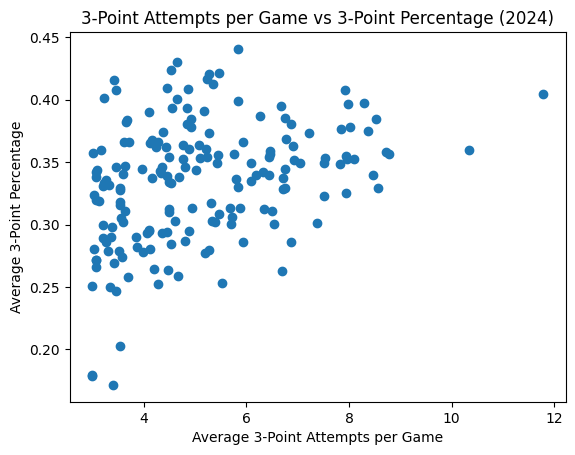

In [18]:
import matplotlib.pyplot as plt

plt.scatter(
    x=avg_player_stats['avg_3pa_per_game'],
    y=avg_player_stats['avg_3p_percentage']
)

plt.title("3-Point Attempts per Game vs 3-Point Percentage (2024)")
plt.xlabel("Average 3-Point Attempts per Game")
plt.ylabel("Average 3-Point Percentage")

plt.show()